# BIVARIATE ANALYSIS

Bivariate analysis is the analysis of the relationship between two variables to understand whether they are associated, how they change together, or whether one variable affects another.

The word "bi" means two, so bivariate analysis deals with two variables at a time.

Types of bivariate analysis:
- Numerical + Numerical
- Categorical + Numerical
- Categorical + Categorical

Difference from univariate analysis:
- Univariate analysis → studies one variable (e.g., distribution of Age)
- Bivariate analysis → studies two variables and their relationship (e.g., Age vs Fare)

In data analysis, bivariate analysis is often used as a step toward finding patterns, relationships, and possible predictive features.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
titanic = pd.read_csv('train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [ ]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Scatterplot ( Numerical - Numerical )

<Axes: xlabel='total_bill', ylabel='tip'>

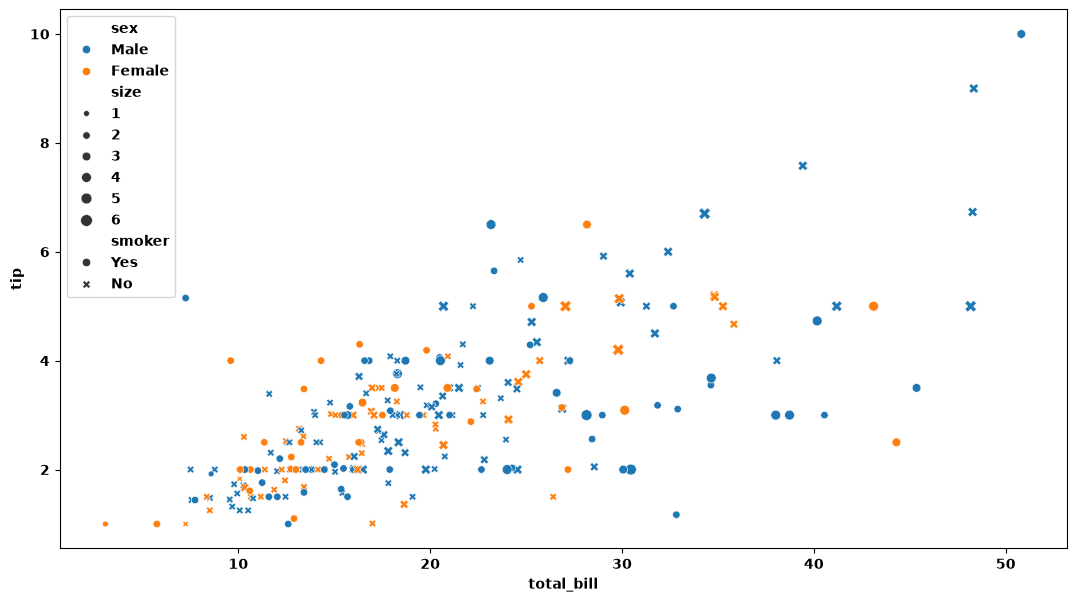

In [18]:
plt.figure(figsize=(13,7))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue=tips['sex'], style=tips['smoker'], size=tips['size'])

Barplot ( Numerical - Categorical )

<Axes: xlabel='Pclass', ylabel='Age'>

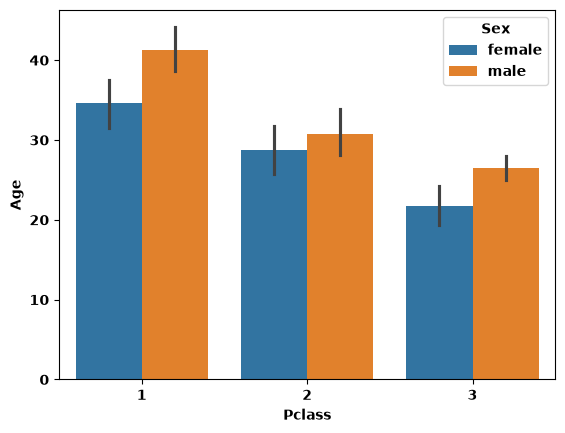

In [21]:
sns.barplot(data=titanic, x='Pclass', y='Age', hue=titanic['Sex'])

Boxplot ( Numerical - Categorical )

<Axes: xlabel='Sex', ylabel='Age'>

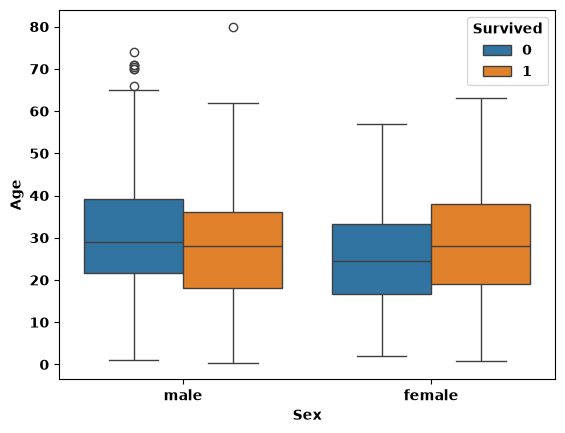

In [24]:
sns.boxplot(data=titanic, x='Sex', y='Age', hue=titanic['Survived'])

Distplot ( Numerical - Categorical )

C:\Users\praja\AppData\Local\Temp\ipykernel_22028\385736575.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']==0]['Age'], hist=False)
C:\Users\praja\AppData\Local\Temp\ipykernel_22028\385736575.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ti

<Axes: xlabel='Age', ylabel='Density'>

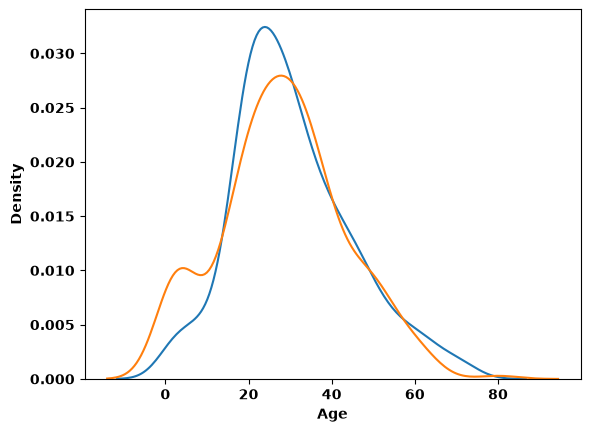

In [26]:
sns.distplot(titanic[titanic['Survived']==0]['Age'], hist=False)
sns.distplot(titanic[titanic['Survived']==1]['Age'], hist=False)

HeadMap (Categorical - Categorical)

In [27]:
pd.crosstab(titanic['Pclass'], titanic['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

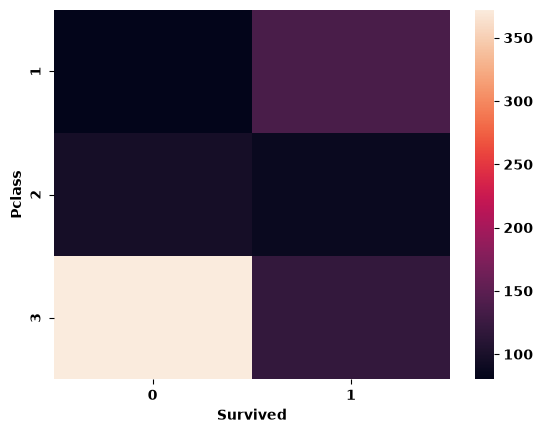

In [28]:
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic['Survived']))

In [ ]:
titanic.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

<Axes: xlabel='Pclass'>

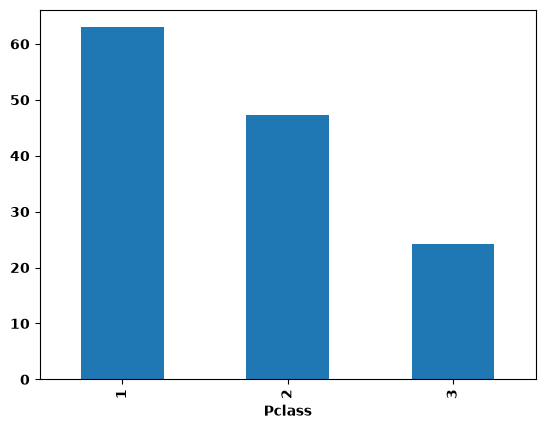

In [32]:
(titanic.groupby('Pclass')['Survived'].mean()*100).plot(kind='bar')

In [33]:
titanic.groupby('Sex')['Survived'].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

<Axes: xlabel='Sex'>

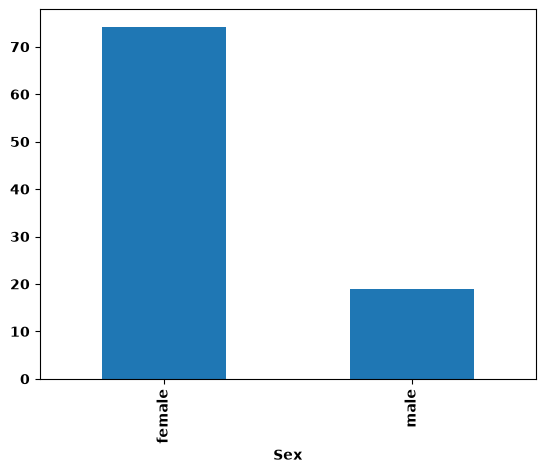

In [34]:
(titanic.groupby('Sex')['Survived'].mean()*100).plot(kind='bar')

In [36]:
titanic.groupby('Embarked')['Survived'].mean()*100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

<Axes: xlabel='Embarked'>

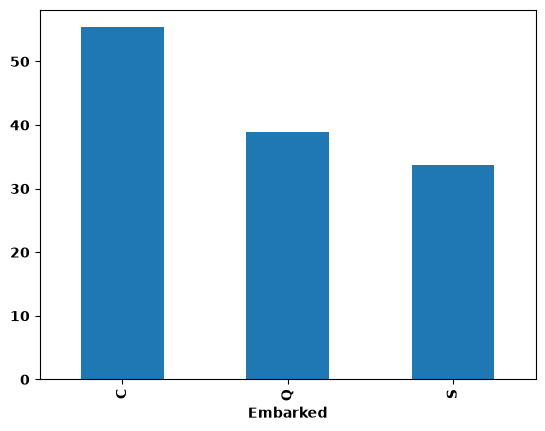

In [35]:
(titanic.groupby('Embarked')['Survived'].mean()*100).plot(kind='bar')


ClusterMap (Categorical - Categorical)

In [37]:
pd.crosstab(titanic['SibSp'], titanic['Survived'])

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


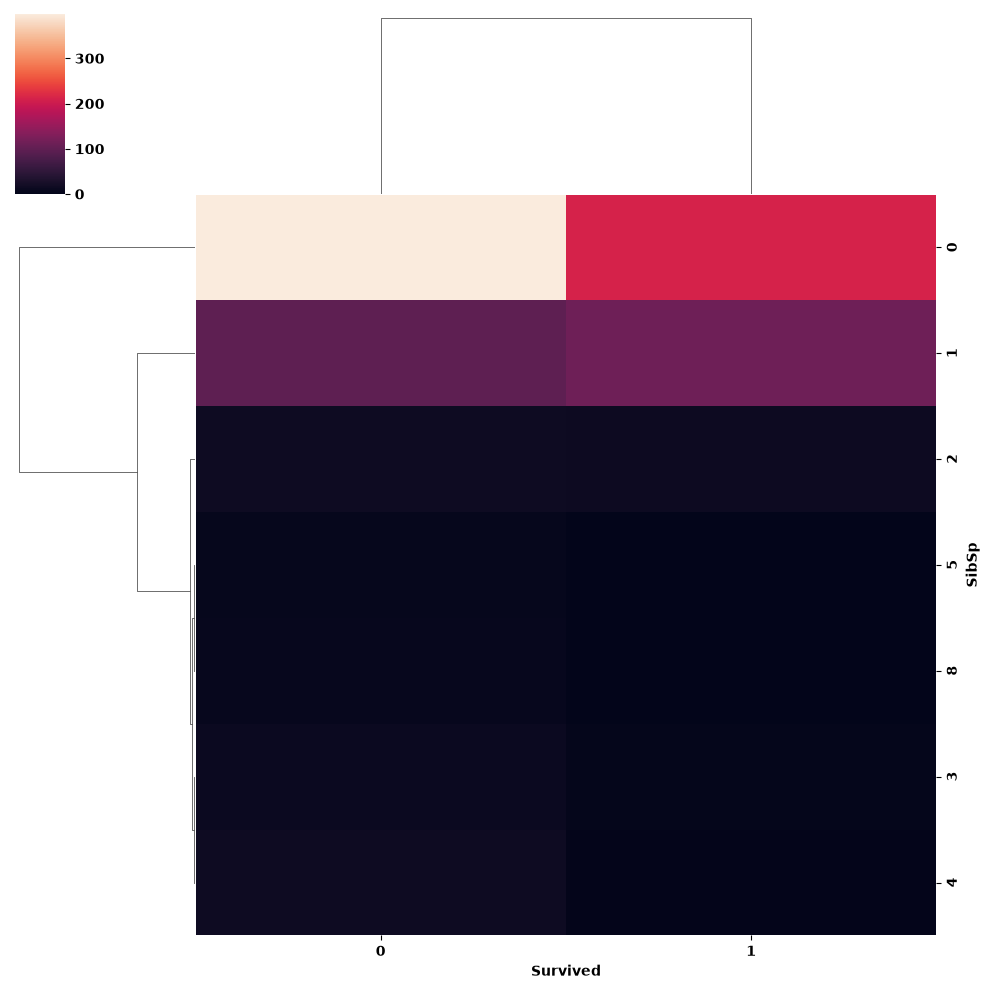

In [ ]:
sns.clustermap(pd.crosstab(titanic['SibSp'], titanic['Survived']))

Pairplot

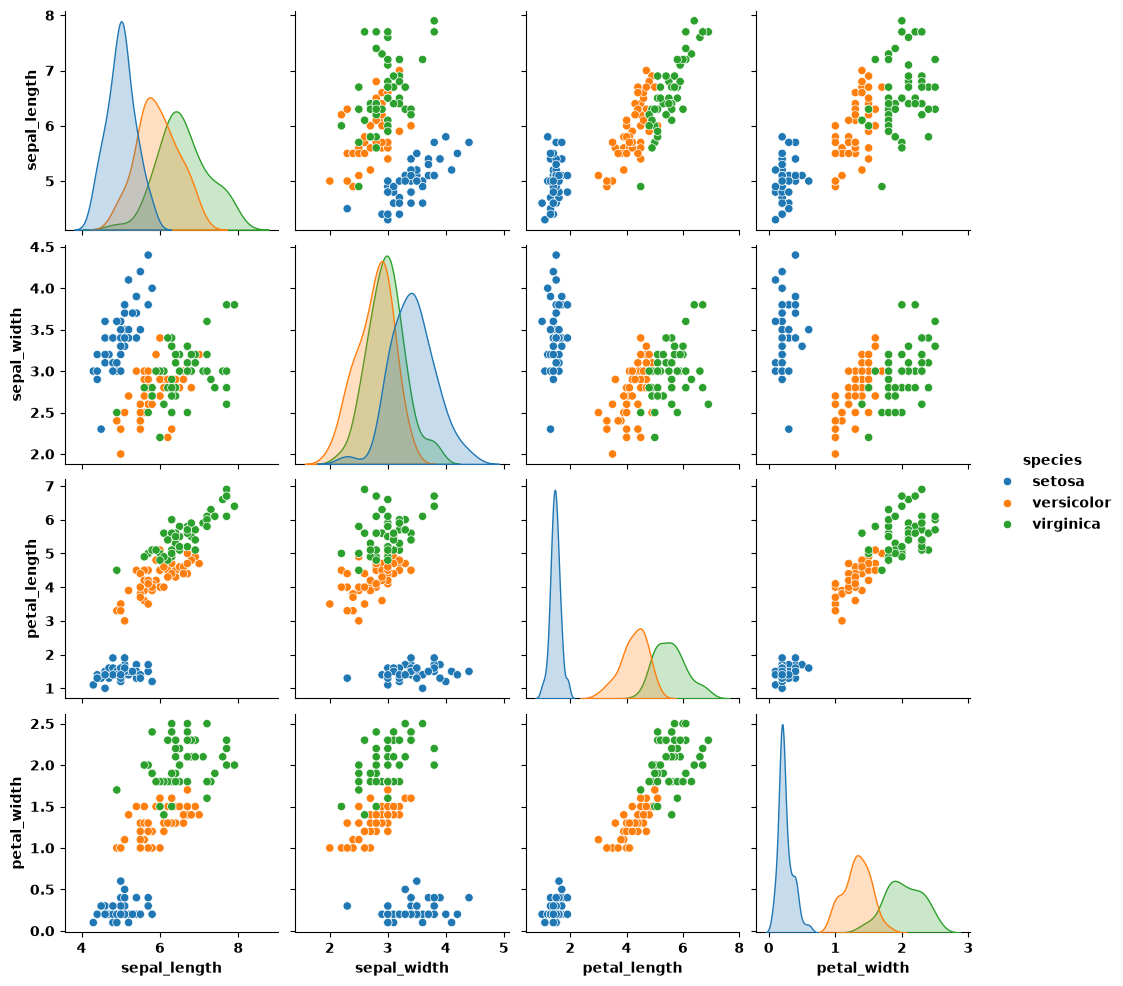

In [40]:
sns.pairplot(iris, hue='species')

LinePlot (Numerical - Numerical)

In [43]:
new = flights.groupby('year')['passengers'].sum().reset_index()
new

,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


<Axes: xlabel='year', ylabel='passengers'>

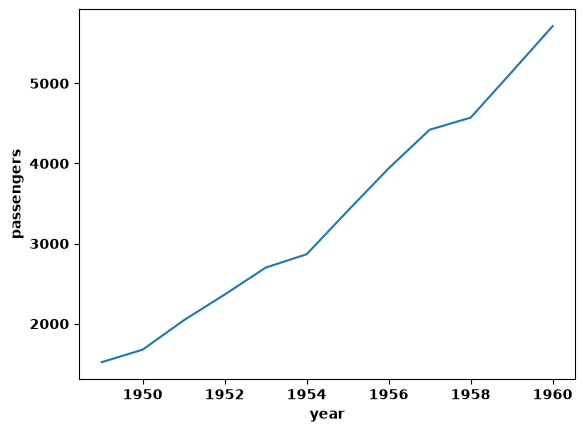

In [45]:
sns.lineplot(x=new['year'], y=new['passengers'])

In [46]:
flights.pivot_table(values='passengers', index='month', columns='year')

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


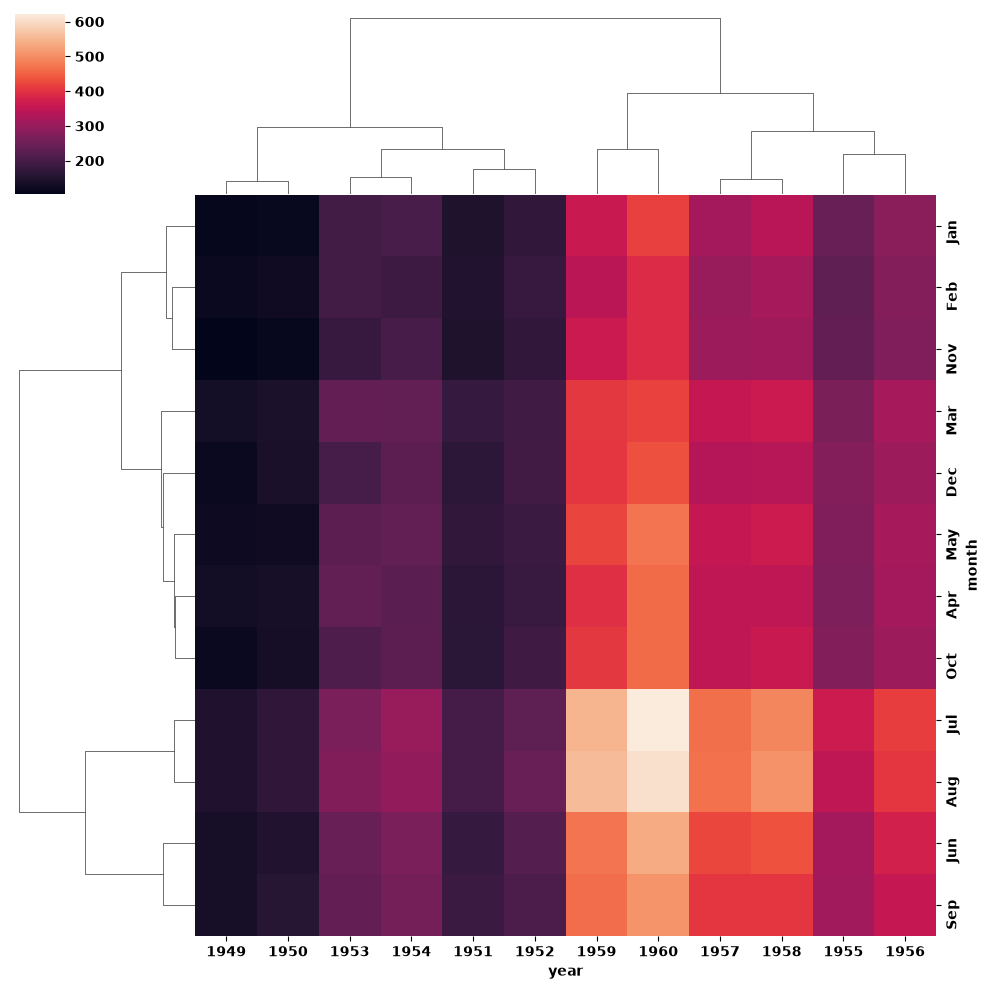

In [48]:
sns.clustermap(flights.pivot_table(values='passengers', index='month', columns='year'))